In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import os 

In [2]:
ruta_carpeta = '/Users/cami/Desktop/cultivos'

In [3]:
archivos = os.listdir (ruta_carpeta) 

archivos = [archivo for archivo in archivos if not '.DS' in archivo]
ruta_archivos = [os.path.join(ruta_carpeta,ruta_archivo) for ruta_archivo in archivos if not'.DS' in ruta_archivo]

for i in range (len(ruta_archivos)):
    print (f'{ruta_archivos[i]}')

/Users/cami/Desktop/cultivos/a - cultivo exp 1_17 nov, 2025.csv
/Users/cami/Desktop/cultivos/a - cultivo exp 2_22 nov, 2025.csv
/Users/cami/Desktop/cultivos/a - cultivo exp 3_08 feb, 2026.csv
/Users/cami/Desktop/cultivos/a - cultivo exp4_22 marzo,2026.csv
/Users/cami/Desktop/cultivos/a - cultivo 1_16 oct.csv


In [4]:
DATOS = []

num_cultivos = len(ruta_archivos)

for num_cultivo, cultivo in enumerate(ruta_archivos):
    
    try:
        cult = pd.read_csv (cultivo)
    
        DATOS.append(cult)
    except Exception as e:
        
        print (e, f'error en archivo {cultivo}')
    

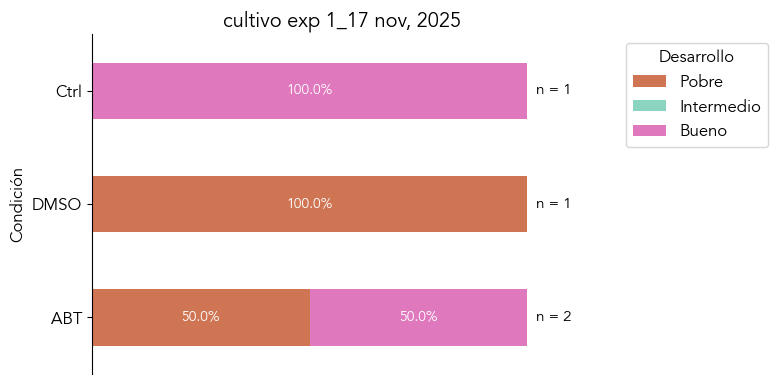

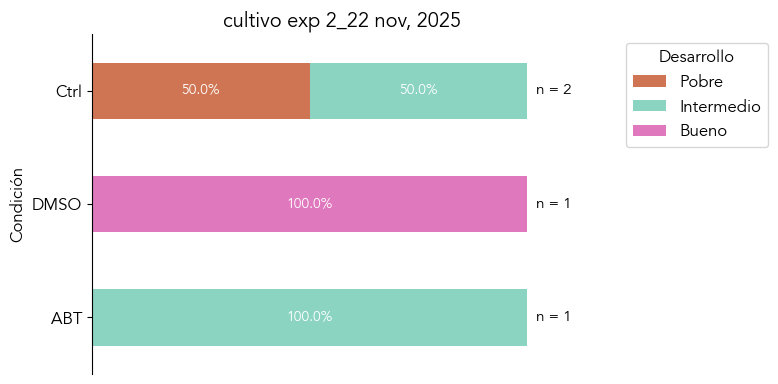

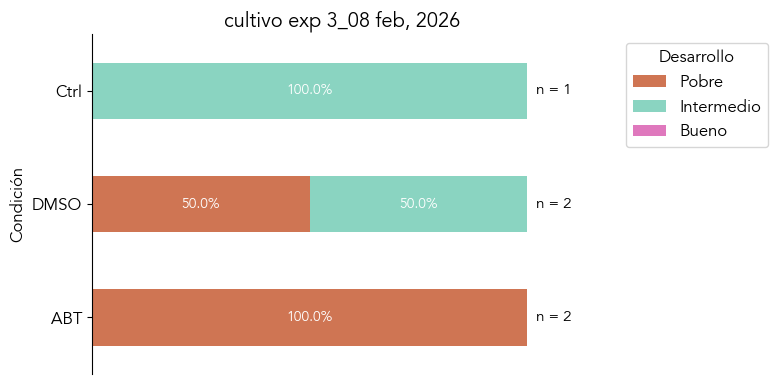

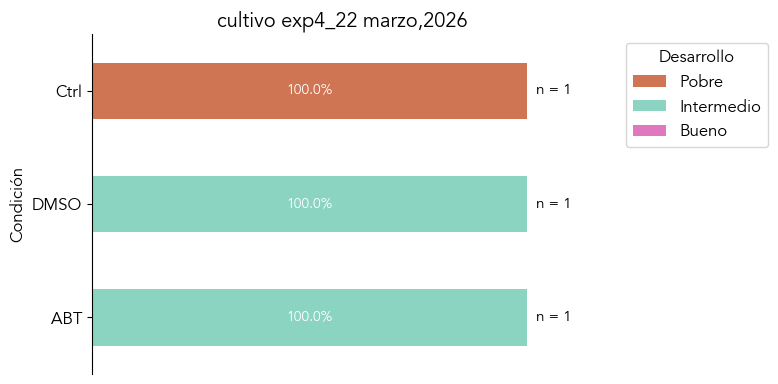

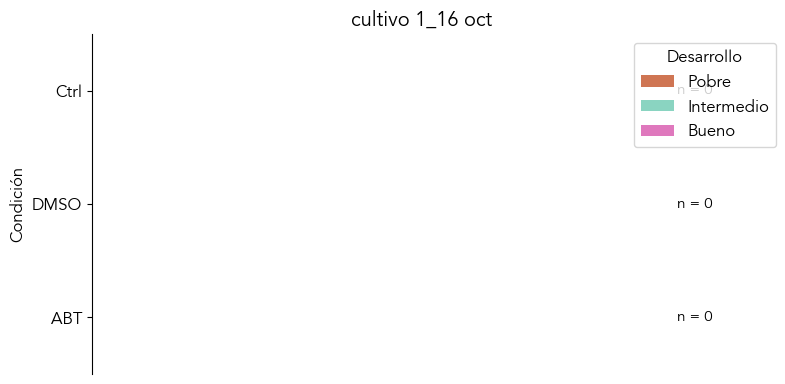

In [6]:
#version de codigo para que salga ctrl, dmso y abt (no funciona para el primer cultivo de condiciones de ml x embrión)
color_map = {
    'Pobre': '#cf7553',
    'Intermedio': '#8ad4c1',
    'Bueno': '#df78bd'
}

orden_desarrollo = ['Pobre', 'Intermedio', 'Bueno']

# Orden deseado de arriba hacia abajo
orden_condiciones = ['Ctrl', 'DMSO', 'ABT']

for idx, cult in enumerate(DATOS):

    # Filtrar solo las condiciones que quieres graficar
    cult_clean = cult[cult['Condición'].isin(orden_condiciones)]

    # Tabla de conteo
    tabla = (
        cult_clean
        .groupby(['Condición', 'Desarrollo'])
        .size()
        .unstack(fill_value=0)
    )

    # Asegurar orden fijo de filas y columnas
    tabla = tabla.reindex(index=orden_condiciones, columns=orden_desarrollo, fill_value=0)

    # Convertir a porcentaje por fila
    tabla_pct = tabla.div(tabla.sum(axis=1), axis=0) * 100

    plt.rcParams['font.family'] = 'Avenir'
    plt.rcParams['font.size'] = 12

    fig, ax = plt.subplots(figsize=(8, 4))

    tabla_pct.plot(
        kind='barh',
        stacked=True,
        ax=ax,
        color=[color_map[d] for d in orden_desarrollo]
    )

    # Para que Ctrl quede arriba, luego DMSO, luego ABT
    ax.invert_yaxis()

    # Quitar bordes
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    ax.set_xticks([])
    ax.tick_params(bottom=False)

    ax.set_xlim(0, 100)
    ax.set_title(f'{archivos[idx][4:-4]}')

    # Tamaño de grupo por condición
    n_por_condicion = tabla.sum(axis=1)

    # Agregar porcentaje dentro de cada segmento
    for j, condicion in enumerate(tabla_pct.index):

        acumulado = 0

        for desarrollo in orden_desarrollo:
            valor = tabla_pct.loc[condicion, desarrollo]

            if valor > 0:
                ax.text(
                    acumulado + valor / 2,
                    j,
                    f'{valor:.1f}%',
                    va='center',
                    ha='center',
                    color='white',
                    fontsize=10
                )

            acumulado += valor

        # Agregar n al final de la barra
        ax.text(
            102,
            j,
            f'n = {int(n_por_condicion.loc[condicion])}',
            va='center',
            ha='left',
            fontsize=11,
            color='black'
        )

    # Ampliar límite para que quepa el texto de n
    ax.set_xlim(0, 115)

    ax.legend(title='Desarrollo', bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.show()